# Build the watershed model

In [390]:
import matplotlib.pyplot as plt
import pathlib as pl
import flopy
from flopy.discretization import StructuredGrid

In [391]:
from defaults import *

In [392]:
model_dir = get_base_dir()

### Load the topology

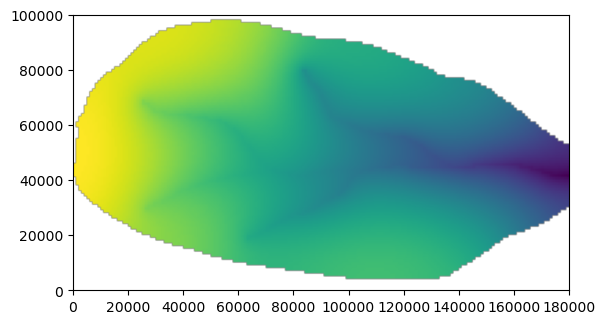

In [393]:
fine_topo = flopy.utils.Raster.load("../../data/Parallel_MODFLOW/fine_topo.tif")
_ = fine_topo.plot()

### Parallel settings

1. Set `path_to_mf6` to the path of parallel MODFLOW 6 (`path\to\mf6`) if it is not in your `PATH` otherwise set to `None`.

In [394]:
path_to_mf6 = None

### Structured grid parameters

Set the cell dimensions. This will determine the number of cells in the grid. Setting dx = dy = 2500.0 will lead to 9595 active cells

In [395]:
dx = dy = 1000.0
nrow = int(Ly / dy) + 1
ncol = int(Lx / dx) + 1

### Read in boundary data

Load the boundary data from `defaults.py` and plot

In [396]:
boundary_polygon = string2geom(geometry["boundary"])
bp = np.array(boundary_polygon)

stream_seg = string2geom(geometry["streamseg1"])
stream_seg = stream_seg[::-1]
stream_seg[:2]

[(25465.838509316767, 68322.98136645963),
 (29347.826086956517, 65093.16770186336)]

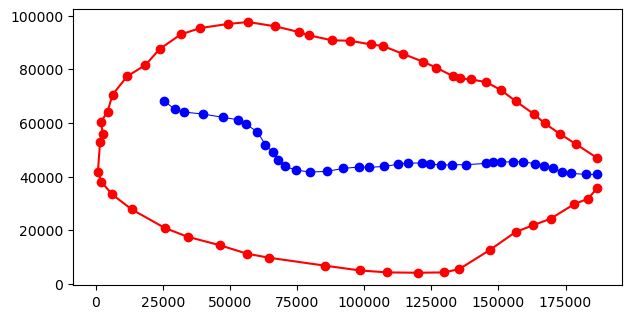

In [397]:
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot()
ax.set_aspect("equal")

riv_colors = ("blue", "cyan", "green", "orange", "red")

ax.plot(bp[:, 0], bp[:, 1], "ro-")
sa = np.array(stream_seg)
ax.plot(sa[:, 0], sa[:, 1], color=riv_colors[0], lw=0.75, marker="o")

In [398]:
stream_seg[:3]

[(25465.838509316767, 68322.98136645963),
 (29347.826086956517, 65093.16770186336),
 (32763.975155279495, 64099.37888198758)]

### Create a structured grid

In [399]:
working_grid = StructuredGrid(
    nlay=1,
    delr=np.full(ncol, dx),
    delc=np.full(nrow, dy),
    xoff=0.0,
    yoff=0.0,
    top=np.full((nrow, ncol), 1000.0),
    botm=np.full((1, nrow, ncol), -100.0),
)

set_structured_idomain(working_grid, boundary_polygon)
print("grid data: ", Lx, Ly, nrow, ncol)

grid data:  180000 100000 101 181


/home/russcher/checkouts/modflow6/.pixi/envs/default/lib/python3.10/site-packages/flopy/utils/gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


### Sample the raw topographic data

In [400]:
top_wg = fine_topo.resample_to_grid(
    working_grid,
    band=fine_topo.bands[0],
    method="linear",
    extrapolate_edges=True,
)

In [401]:
# top_wg = np.ones_like(top_wg)
# for i in range(nrow):
#     for j in range(ncol):
#         top_wg[i,j] = ncol - top_wg[i,j] * j - 1
# top_wg

### Intersect river segments with grid

In [402]:
working_grid.top.min()

1000.0

In [403]:
ixs = flopy.utils.GridIntersect(
        working_grid,
    )
v = ixs.intersect(LineString(stream_seg), sort_by_cellid=False)
cellids = v['cellids']

/home/russcher/checkouts/modflow6/.pixi/envs/default/lib/python3.10/site-packages/flopy/utils/gridintersect.py:290: DeprecationWarning: In the future this function will return a GeoDataFrame by default. Set geo_dataframe=True to adopt future behavior and silence this warning. Set geo_dataframe=False to silence this warning and maintain old behavior
  warnings.warn(


In [404]:
intersection_rg = np.zeros(working_grid.shape[1:])
for loc in cellids:
    intersection_rg[loc] = 1

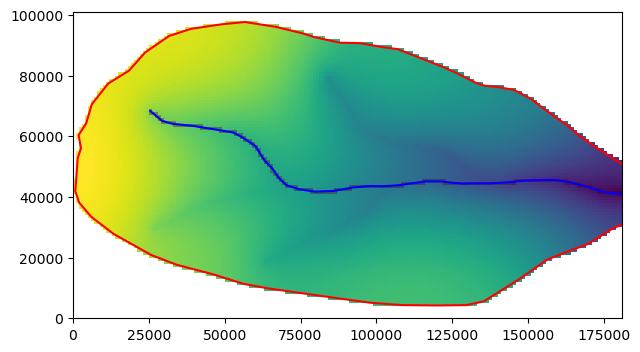

In [405]:
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot()
pmv = flopy.plot.PlotMapView(modelgrid=working_grid)
ax.set_aspect("equal")
pmv.plot_array(top_wg)
pmv.plot_array(
    intersection_rg,
    masked_values=[
        0,
    ],
    alpha=0.2,
    cmap="Reds_r",
)
pmv.plot_inactive(color_noflow="white")
ax.plot(bp[:, 0], bp[:, 1], "r-")
sa = np.array(stream_seg)
ax.plot(sa[:, 0], sa[:, 1], "b-")

### Set the idomain value to 2 where the river intersects the grid

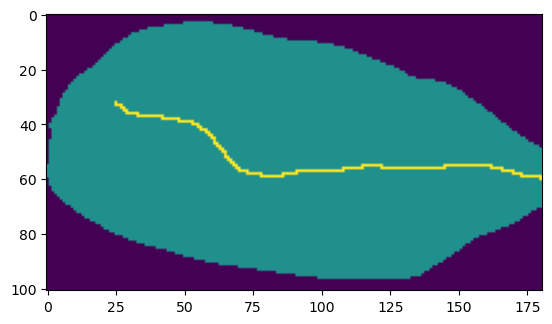

In [406]:
river_locations = working_grid.idomain[0].copy()
index = tuple(np.array(list(zip(*cellids))))
river_locations[index] = 2
working_grid.idomain = river_locations.reshape(1, nrow, ncol)

plt.imshow(working_grid.idomain[0])

### Define the number of layers and the thickness of layer 1

In [407]:
nlay = 5
dv0 = 5.0
# is this reasonable???
leakance = 1.0 / (0.5 * dv0)  # Kv / b  [1/m]

### Create the SFR data for the reaches

In [408]:
# Build SFR inputs from the stream/grid intersection results in `v`
# Assumes: v, sg, top_wg, leakance already exist
stream_line = LineString(stream_seg)

# Collect and sort intersections along stream direction
_reaches = []
for rec in v:
    i, j = rec["cellids"]
    rlen = float(rec["lengths"])
    midpt = rec["ixshapes"].interpolate(0.5, normalized=True)
    dist = float(stream_line.project(midpt))
    cell_top = float(top_wg[i, j])
    _reaches.append((dist, int(i), int(j), rlen, cell_top))
    
_reaches.sort(key=lambda x: x[0])
_reaches[:2]

[(252.49516758228637, 32, 25, 504.99033516457, 86.66666412353516),
 (599.9285181755096, 33, 25, 189.87636602187274, 86.66666412353516)]

In [409]:
# regularize stream bed
for r in range(1,len(_reaches)-1):
    bl_prev = _reaches[r-1][4]
    bl = _reaches[r][4]
    bl_next = _reaches[r+1][4]
    if bl > bl_prev:
        # put it in between, or at least flat
        new_bl = min(0.5*(bl_next + bl_prev), bl_prev)
        _reaches[r] = _reaches[r][:4] + (new_bl,)

In [410]:
nreaches = len(_reaches)

# Hydraulic parameters (edit if needed)
rwid = 25.0   # reach width
rbth = 1.0    # streambed thickness
rhk = 0.1 #1.0     # streambed hydraulic conductivity
man = 0.035   # Manning's n

# Build MF6 SFR packagedata and connectiondata
sfr_packagedata = []
sfr_connectiondata = []

for rno, (dist, i, j, rlen, cell_top) in enumerate(_reaches):
    # streambed top
    rtp = cell_top - 1.0

    # slope from next reach (or previous for last reach)
    if rno < nreaches - 1:
        dist2, _, _, _, top2 = _reaches[rno + 1]
        dd = max(dist2 - dist, 1.0)
        dz = max(cell_top - top2, 1e-3)
    elif nreaches > 1:
        dist1, _, _, _, top1 = _reaches[rno - 1]
        dd = max(dist - dist1, 1.0)
        dz = max(top1 - cell_top, 1e-3)
    else:
        dd, dz = 1.0, 1e-3

    rgrd = max(dz / dd, 1e-5)
    ncon = int(rno > 0) + int(rno < nreaches - 1)

    # ifno, cellid, rlen, rwid, rgrd, rtp, rbth, rhk, man, ncon, ustrf, ndv
    sfr_packagedata.append(
        (rno, (0, i, j), rlen, rwid, rgrd, rtp, rbth, rhk, man, ncon, 1.0, 0)
    )

    # Connection convention: upstream positive, downstream negative
    conn = [rno]
    if rno > 0:
        conn.append(rno - 1)
    if rno < nreaches - 1:
        conn.append(-(rno + 1))
    sfr_connectiondata.append(conn)

# Stress period data (set inflow at first reach; adjust as needed)
sfr_perioddata = {0: [(0, "inflow", 0.0)]}

# Initial stage data (set to streambed top for each reach)
sfr_initialstages = [(rno, float(rec[5])) for rno, rec in enumerate(sfr_packagedata)]

# Optional: DRN river proxy using same intersections (used later by ModflowGwfdrn)
drn_data = []
for rno, (_, i, j, rlen, cell_top) in enumerate(_reaches):
    elev = cell_top - 1.0
    cond = leakance * rlen * rwid
    drn_data.append(((0, i, j), elev, cond))

print(f"SFR reaches: {nreaches}")
print("Example packagedata row:", sfr_packagedata[0] if nreaches else None)
print("Example connection row:", sfr_connectiondata[0] if nreaches else None)

SFR reaches: 194
Example packagedata row: (0, (0, 32, 25), 504.99033516457, 25.0, 1e-05, 85.66666412353516, 1.0, 0.1, 0.035, 1, 1.0, 0)
Example connection row: [0, -1]


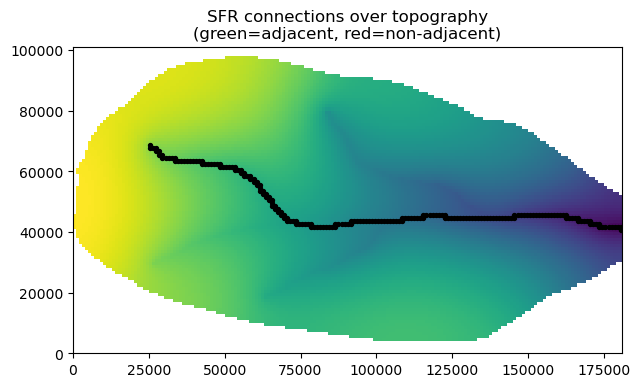

Total SFR connections checked: 193
Non-adjacent connections: 0


In [411]:
# Plot SFR reach-to-reach connections on topography and flag non-adjacent links

# Build reach -> (row, col) map from sfr_packagedata
reach_rc = {}
for rec in sfr_packagedata:
    rno = int(rec[0])
    _, i, j = rec[1]  # cellid is (k, i, j)
    reach_rc[rno] = (int(i), int(j))

# Build unique connection pairs from sfr_connectiondata
pairs = set()
for conn in sfr_connectiondata:
    rno = int(conn[0])
    for c in conn[1:]:
        cabs = abs(int(c))
        if cabs in reach_rc and rno in reach_rc and cabs != rno:
            pairs.add(tuple(sorted((rno, cabs))))

# Check adjacency and collect bad pairs
bad_pairs = []
for a, b in sorted(pairs):
    ia, ja = reach_rc[a]
    ib, jb = reach_rc[b]
    di, dj = abs(ia - ib), abs(ja - jb)
    is_adjacent = (max(di, dj) == 1)  # adjacent by edge or corner
    if not is_adjacent:
        bad_pairs.append((a, b, (ia, ja), (ib, jb), di, dj))

# Plot
fig, ax = plt.subplots(figsize=figsize)
pmv = flopy.plot.PlotMapView(modelgrid=working_grid, ax=ax)
pmv.plot_array(top_wg)
pmv.plot_inactive(color_noflow="white")
ax.set_aspect("equal")
ax.set_title("SFR connections over topography\n(green=adjacent, red=non-adjacent)")

xcc = working_grid.xcellcenters
ycc = working_grid.ycellcenters

# Draw connection lines
for a, b in sorted(pairs):
    ia, ja = reach_rc[a]
    ib, jb = reach_rc[b]
    xa, ya = xcc[ia, ja], ycc[ia, ja]
    xb, yb = xcc[ib, jb], ycc[ib, jb]
    di, dj = abs(ia - ib), abs(ja - jb)
    color = "lime" if max(di, dj) == 1 else "red"
    ax.plot([xa, xb], [ya, yb], color=color, lw=1.5, alpha=0.9)

# Plot reach centers
rx = [xcc[i, j] for i, j in reach_rc.values()]
ry = [ycc[i, j] for i, j in reach_rc.values()]
ax.scatter(rx, ry, s=8, c="k", zorder=3)

plt.show()

# Report non-adjacent connections
print(f"Total SFR connections checked: {len(pairs)}")
print(f"Non-adjacent connections: {len(bad_pairs)}")
for a, b, rc_a, rc_b, di, dj in bad_pairs[:25]:
    print(f"  {a} ({rc_a}) <-> {b} ({rc_b})  |  drow={di}, dcol={dj}")
if len(bad_pairs) > 25:
    print(f"  ... {len(bad_pairs) - 25} more")

### Create the groundwater discharge drain data

In [412]:
gw_discharge_data = build_groundwater_discharge_data(
    working_grid,
    leakance,
    top_wg,
)
gw_discharge_data[:10]

[(0, 3, 50, 97.20894622802734, 400000.0, 1.0),
 (0, 3, 51, 97.02515411376953, 400000.0, 1.0),
 (0, 3, 52, 96.7613525390625, 400000.0, 1.0),
 (0, 3, 53, 96.45259857177734, 400000.0, 1.0),
 (0, 3, 54, 96.11321258544922, 400000.0, 1.0),
 (0, 3, 55, 95.75077056884766, 400000.0, 1.0),
 (0, 3, 56, 95.37101745605469, 400000.0, 1.0),
 (0, 3, 57, 94.9806137084961, 400000.0, 1.0),
 (0, 3, 58, 94.59060668945312, 400000.0, 1.0),
 (0, 3, 59, 94.2248764038086, 400000.0, 1.0)]

### Create the top and bottom arrays.

Top array is not used by the model.

In [413]:
topc = np.zeros((nlay, nrow, ncol), dtype=float)
botm = np.zeros((nlay, nrow, ncol), dtype=float)
dv = dv0
topc[0] = top_wg.copy()
botm[0] = topc[0] - dv
for idx in range(1, nlay):
    dv *= 1.5
    topc[idx] = botm[idx - 1]
    botm[idx] = topc[idx] - dv

#### Print the cell thicknesses

In [414]:
for k in range(nlay):
    print((topc[k] - botm[k]).mean())

5.0
7.5
11.25
16.875
25.3125


### Create idomain and starting head data

In [415]:
idomain = np.array([working_grid.idomain[0, :, :].copy() for k in range(nlay)])
strt = np.array([top_wg.copy() for k in range(nlay)], dtype=float)

## Build the model files using FloPy
Note that the CSV solver output is enabled. We will use that in one of the other notebooks.

In [416]:
sim = flopy.mf6.MFSimulation(
    sim_ws=model_dir,
    exe_name="mf6",
    memory_print_option="summary",
)

tdis = flopy.mf6.ModflowTdis(sim, nper=1, perioddata=[(10.0,10,1.0)])
ims = flopy.mf6.ModflowIms(
    sim,
    complexity="simple",
    print_option="SUMMARY",
    csv_outer_output_filerecord="outer.csv",
    csv_inner_output_filerecord="inner.csv",
    linear_acceleration="bicgstab",
    outer_maximum=1000,
    inner_maximum=100,
    outer_dvclose=1e-4,
    inner_dvclose=1e-5,
    preconditioner_levels=2,
    relaxation_factor=0.0,
)
gwf = flopy.mf6.ModflowGwf(
    sim,
    print_input=False,
    save_flows=True,
    newtonoptions="NEWTON UNDER_RELAXATION",
)

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=dx,
    delc=dy,
    idomain=idomain,
    top=top_wg,
    botm=botm,
    xorigin=0.0,
    yorigin=0.0,
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=strt)
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_specific_discharge=True,
    icelltype=1,
    k=1.0,
)
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    save_flows=True,
    iconvert=1,
    ss=1e-6,
    sy=0.2,
    steady_state={0: False},
    transient={0: True},
)

rch = flopy.mf6.ModflowGwfrcha(
    gwf,
    recharge=0.000001,
)

sfr = flopy.mf6.ModflowGwfsfr(
    gwf,
    pname="sfr",
    filename="sfr.sfr",
    save_flows=True,
    print_input=False,
    stage_filerecord="stages.sfr.bin",
    nreaches=nreaches,
    packagedata=sfr_packagedata,
    connectiondata=sfr_connectiondata,
    initialstages=sfr_initialstages,
    perioddata=sfr_perioddata,
)

drn_gwd = flopy.mf6.ModflowGwfdrn(
    gwf,
    auxiliary=["depth"],
    auxdepthname="depth",
    stress_period_data=gw_discharge_data,
    pname="gwd",
    filename="drn_gwd.drn",
)

oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{gwf.name}.hds",
    budget_filerecord=f"{gwf.name}.cbc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("BUDGET", "ALL")],
)

### Count the number of active cells

In [417]:
ncells, nactive = get_simulation_cell_count(sim)
print("nr. of cells:", ncells, ", active:", nactive)

nr. of cells: 91405 , active: 61790


### Write the model files

In [418]:
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model model...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package rcha_0...
    writing package sfr...
    writing package gwd...
INFORMATION: maxbound in ('', 'drn', 'dimensions') changed to 12358 based on size of stress_period_data
    writing package oc...


### Run the model

In [419]:
sim.run_simulation()

FloPy is using the following executable to run the model: ../../../../../modflow6/bin/mf6
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                  VERSION 6.8.0.dev0 (preliminary) 02/06/2026
                               ***DEVELOP MODE***

        MODFLOW 6 compiled May 20 2026 16:55:45 with GCC version 13.3.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the so

(True, [])

### Plot results

In [420]:
gwf = sim.get_model()
times = gwf.output.head().get_times()
base_head = np.squeeze(gwf.output.head().get_data(totim=times[-1]))

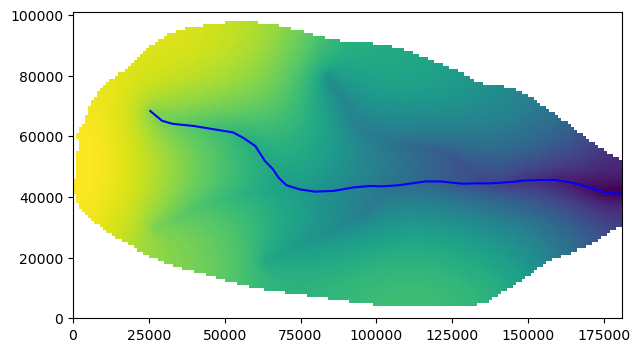

In [421]:
fig = plt.figure(figsize=figsize)
pmv = flopy.plot.PlotMapView(model=gwf, layer=0)
pmv.plot_array(base_head)

sa = np.array(stream_seg)
pmv.ax.plot(sa[:, 0], sa[:, 1], "b-")

In [426]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

sfr_pkg = gwf.get_package("sfr")
stage_obj = sfr_pkg.output.stage()

stage_times = stage_obj.get_times()
stage_all = np.array([np.squeeze(stage_obj.get_data(totim=t)) for t in stage_times])

reach_lengths = np.array([rec[2] for rec in sfr_packagedata], dtype=float)
stream_dist = np.cumsum(reach_lengths) - 0.5 * reach_lengths

fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot(stream_dist, stage_all[0], lw=2)
ax.set_xlabel("Distance along stream")
ax.set_ylabel("Stage")
ax.set_xlim(stream_dist.min(), stream_dist.max())
ax.set_ylim(np.nanmin(stage_all), np.nanmax(stage_all))
title = ax.set_title(f"t = {stage_times[0]:.2f}")

def update(i):
    line.set_ydata(stage_all[i])
    title.set_text(f"Stage along stream vs. distance, t = {stage_times[i]:.2f}")
    return line, title

anim = FuncAnimation(fig, update, frames=len(stage_times), interval=300, blit=True)
plt.close(fig)

riverbed = np.array([rec[5] for rec in sfr_packagedata], dtype=float)  # rtp from SFR packagedata

ax.plot(stream_dist, riverbed, "k--", lw=1.5, label="Riverbed")
ax.legend(loc="best")


HTML(anim.to_jshtml())

In [431]:
from flopy.mf6.utils.model_splitter import Mf6Splitter

In [433]:
splitter = Mf6Splitter(sim)
mask = splitter.optimize_splitting_mask(nparts=2)
splitter.split_model(mask)

ImportError: Missing optional dependency 'pymetis'. please install pymetis using: conda install -c conda-forge pymetis Use pip or conda to install pymetis.